In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("✓ Setup listo")

✓ Setup listo


In [2]:
# ============================================================
# S4.4 — VECTORES Y OPERACIONES BÁSICAS
# ============================================================

# Un vector = un cliente representado por sus atributos
# En RFM: [Recencia, Frecuencia, Monto]

cliente_A = np.array([15, 8, 450])   # compró hace 15 días, 8 veces, $450 promedio
cliente_B = np.array([3, 25, 1200])  # compró hace 3 días, 25 veces, $1200 promedio
cliente_C = np.array([60, 2, 80])    # compró hace 60 días, 2 veces, $80 promedio

print("=== VECTORES RFM ===")
print(f"Cliente A: {cliente_A}  → cliente frecuente medio")
print(f"Cliente B: {cliente_B}  → cliente VIP reciente")
print(f"Cliente C: {cliente_C}  → cliente dormido de bajo valor")

# --- OPERACIONES BÁSICAS ---
print("\n=== OPERACIONES ===")

# Suma de vectores
suma = cliente_A + cliente_B
print(f"A + B = {suma}  ← suma componente a componente")

# Multiplicación por escalar
doble_A = 2 * cliente_A
print(f"2 × A = {doble_A}  ← cada componente se multiplica")

# Diferencia — dirección de un cliente a otro
diff = cliente_B - cliente_A
print(f"B - A = {diff}  ← qué tan diferente es B respecto a A")

# --- NORMA (magnitud del vector) ---
# Fórmula: ||v|| = √(v₁² + v₂² + v₃²)
norma_A = np.linalg.norm(cliente_A)
norma_B = np.linalg.norm(cliente_B)
norma_C = np.linalg.norm(cliente_C)

print(f"\n=== NORMA (magnitud) ===")
print(f"||A|| = {norma_A:.2f}")
print(f"||B|| = {norma_B:.2f}")
print(f"||C|| = {norma_C:.2f}")
print(f"\nEl cliente con mayor 'magnitud' en RFM es: B (${norma_B:.0f})")
print(f"Interpretación: B tiene el perfil más 'intenso' en todas las dimensiones")

=== VECTORES RFM ===
Cliente A: [ 15   8 450]  → cliente frecuente medio
Cliente B: [   3   25 1200]  → cliente VIP reciente
Cliente C: [60  2 80]  → cliente dormido de bajo valor

=== OPERACIONES ===
A + B = [  18   33 1650]  ← suma componente a componente
2 × A = [ 30  16 900]  ← cada componente se multiplica
B - A = [-12  17 750]  ← qué tan diferente es B respecto a A

=== NORMA (magnitud) ===
||A|| = 450.32
||B|| = 1200.26
||C|| = 100.02

El cliente con mayor 'magnitud' en RFM es: B ($1200)
Interpretación: B tiene el perfil más 'intenso' en todas las dimensiones


In [3]:
# ============================================================
# S4.4 — DISTANCIAS: EUCLIDIANA Y MANHATTAN
# ============================================================

from scipy.spatial.distance import euclidean, cityblock

# Usamos solo R y F para poder visualizar en 2D
# En práctica real usarías las 3 dimensiones normalizadas

A = np.array([15, 8])
B = np.array([3, 25])
C = np.array([60, 2])

# --- DISTANCIA EUCLIDIANA ---
# Fórmula: √( Σ(aᵢ - bᵢ)² )
# = raíz de la suma de diferencias al cuadrado

dist_AB_euc = euclidean(A, B)
dist_AC_euc = euclidean(A, C)
dist_BC_euc = euclidean(B, C)

# --- DISTANCIA MANHATTAN ---
# Fórmula: Σ|aᵢ - bᵢ|
# = suma de diferencias absolutas

dist_AB_man = cityblock(A, B)
dist_AC_man = cityblock(A, C)
dist_BC_man = cityblock(B, C)

print("=== DISTANCIAS ENTRE CLIENTES (R, F) ===")
print(f"{'Par':<8} {'Euclidiana':>12} {'Manhattan':>12}  Interpretación")
print("-" * 60)
print(f"{'A vs B':<8} {dist_AB_euc:>12.2f} {dist_AB_man:>12.2f}  ← más parecidos")
print(f"{'A vs C':<8} {dist_AC_euc:>12.2f} {dist_AC_man:>12.2f}")
print(f"{'B vs C':<8} {dist_BC_euc:>12.2f} {dist_BC_man:>12.2f}  ← más diferentes")

print("\n=== CONCLUSIÓN ===")
pares = {'A-B': dist_AB_euc, 'A-C': dist_AC_euc, 'B-C': dist_BC_euc}
mas_cercanos = min(pares, key=pares.get)
print(f"Par más similar:   {mas_cercanos} (distancia: {min(pares.values()):.2f})")
print(f"Par más diferente: B-C (distancia: {dist_BC_euc:.2f})")
print(f"\nEn k-means: A y B irían probablemente al mismo cluster.")
print(f"C quedaría en su propio cluster (cliente dormido).")

=== DISTANCIAS ENTRE CLIENTES (R, F) ===
Par        Euclidiana    Manhattan  Interpretación
------------------------------------------------------------
A vs B          20.81        29.00  ← más parecidos
A vs C          45.40        51.00
B vs C          61.47        80.00  ← más diferentes

=== CONCLUSIÓN ===
Par más similar:   A-B (distancia: 20.81)
Par más diferente: B-C (distancia: 61.47)

En k-means: A y B irían probablemente al mismo cluster.
C quedaría en su propio cluster (cliente dormido).


In [4]:
# ============================================================
# S4.4 — NORMALIZACIÓN Y PRODUCTO PUNTO
# ============================================================

# --- NORMALIZACIÓN MIN-MAX ---
# Problema actual: Monto ($450) domina sobre R (15) y F (8)
# Solución: escalar todo a [0,1]

# Valores mínimos y máximos del dataset
rfm_raw = np.array([
    [15,  8,  450],   # A
    [3,  25, 1200],   # B
    [60,  2,   80],   # C
])

rfm_min = rfm_raw.min(axis=0)   # mínimo por columna
rfm_max = rfm_raw.max(axis=0)   # máximo por columna

rfm_norm = (rfm_raw - rfm_min) / (rfm_max - rfm_min)

print("=== NORMALIZACIÓN MIN-MAX ===")
print(f"{'Cliente':<10} {'R_raw':>8} {'F_raw':>8} {'M_raw':>8} │ "
      f"{'R_norm':>8} {'F_norm':>8} {'M_norm':>8}")
print("-" * 70)
for i, (nombre, raw, norm) in enumerate(zip(['A','B','C'], rfm_raw, rfm_norm)):
    print(f"{nombre:<10} {raw[0]:>8} {raw[1]:>8} {raw[2]:>8} │ "
          f"{norm[0]:>8.3f} {norm[1]:>8.3f} {norm[2]:>8.3f}")

# Distancias ANTES vs DESPUÉS de normalizar
print("\n=== IMPACTO DE NORMALIZACIÓN EN DISTANCIAS ===")
for par, (i,j) in [('A-B',(0,1)), ('A-C',(0,2)), ('B-C',(1,2))]:
    d_antes = euclidean(rfm_raw[i], rfm_raw[j])
    d_despues = euclidean(rfm_norm[i], rfm_norm[j])
    print(f"{par}: antes={d_antes:.1f}  después={d_despues:.3f}")

print()

# --- PRODUCTO PUNTO ---
# Fórmula: a · b = Σ(aᵢ × bᵢ)
# Mide qué tanto apuntan en la misma dirección dos vectores
# Resultado = 0 → perpendiculares (sin relación)
# Resultado alto → apuntan en la misma dirección (clientes similares)

A_n = rfm_norm[0]
B_n = rfm_norm[1]
C_n = rfm_norm[2]

pp_AB = np.dot(A_n, B_n)
pp_AC = np.dot(A_n, C_n)
pp_BC = np.dot(B_n, C_n)

print("=== PRODUCTO PUNTO (vectores normalizados) ===")
print(f"A · B = {pp_AB:.4f}  ← alta similitud de dirección")
print(f"A · C = {pp_AC:.4f}")
print(f"B · C = {pp_BC:.4f}  ← poca similitud")
print()

# Similitud coseno = producto punto / (norma_A × norma_B)
# Mide el ÁNGULO entre vectores — ignora la magnitud
cos_AB = pp_AB / (np.linalg.norm(A_n) * np.linalg.norm(B_n))
cos_AC = pp_AC / (np.linalg.norm(A_n) * np.linalg.norm(C_n))
cos_BC = pp_BC / (np.linalg.norm(B_n) * np.linalg.norm(C_n))

print("=== SIMILITUD COSENO ===")
print(f"cos(A,B) = {cos_AB:.4f}  → ángulo: {np.degrees(np.arccos(cos_AB)):.1f}°")
print(f"cos(A,C) = {cos_AC:.4f}  → ángulo: {np.degrees(np.arccos(cos_AC)):.1f}°")
print(f"cos(B,C) = {cos_BC:.4f}  → ángulo: {np.degrees(np.arccos(cos_BC)):.1f}°")
print()
print("Ángulo pequeño = clientes similares en perfil")
print("Ángulo grande  = clientes con perfiles opuestos")

=== NORMALIZACIÓN MIN-MAX ===
Cliente       R_raw    F_raw    M_raw │   R_norm   F_norm   M_norm
----------------------------------------------------------------------
A                15        8      450 │    0.211    0.261    0.330
B                 3       25     1200 │    0.000    1.000    1.000
C                60        2       80 │    1.000    0.000    0.000

=== IMPACTO DE NORMALIZACIÓN EN DISTANCIAS ===
A-B: antes=750.3  después=1.019
A-C: antes=372.8  después=0.895
B-C: antes=1121.7  después=1.732

=== PRODUCTO PUNTO (vectores normalizados) ===
A · B = 0.5912  ← alta similitud de dirección
A · C = 0.2105
B · C = 0.0000  ← poca similitud

=== SIMILITUD COSENO ===
cos(A,B) = 0.8883  → ángulo: 27.3°
cos(A,C) = 0.4473  → ángulo: 63.4°
cos(B,C) = 0.0000  → ángulo: 90.0°

Ángulo pequeño = clientes similares en perfil
Ángulo grande  = clientes con perfiles opuestos


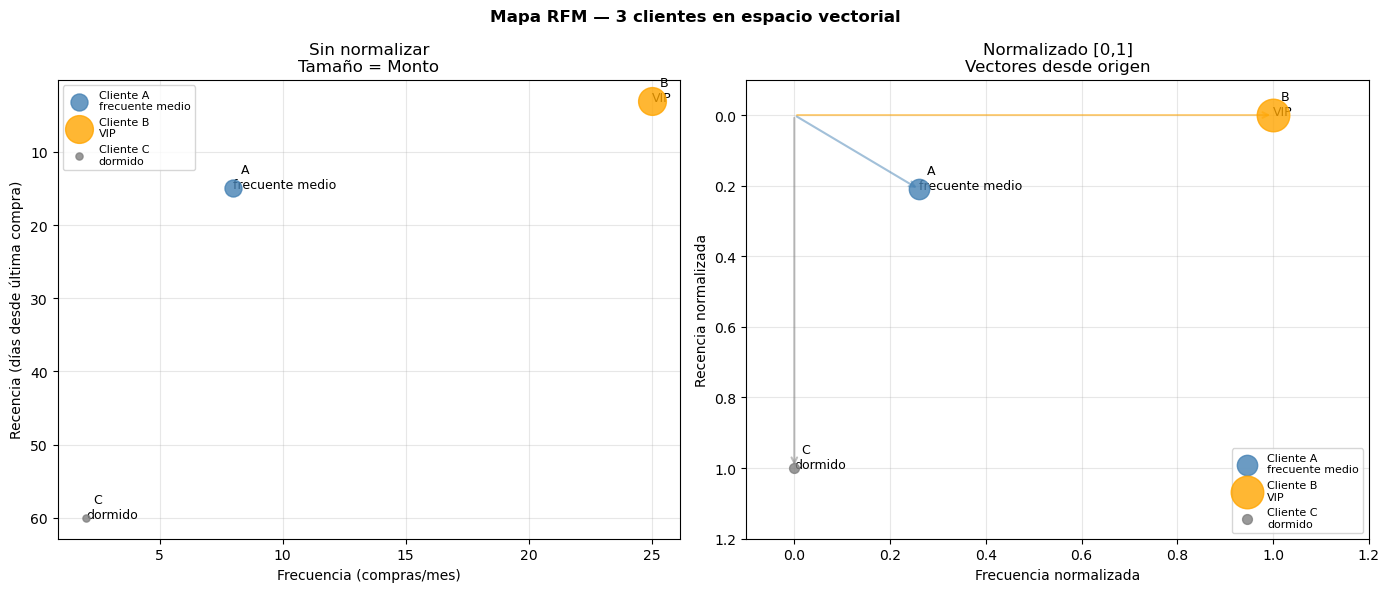

In [5]:
# ============================================================
# S4.4 — VISUALIZACIÓN: MAPA DE CLIENTES RFM NORMALIZADO
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

clientes = ['A\nfrecuente medio', 'B\nVIP', 'C\ndormido']
colores  = ['steelblue', 'orange', 'gray']

# --- Plot 1: Espacio R vs F (sin normalizar) ---
ax = axes[0]
for i, (c, col) in enumerate(zip(clientes, colores)):
    ax.scatter(rfm_raw[i,1], rfm_raw[i,0],
               s=rfm_raw[i,2]/3, color=col, alpha=0.8,
               label=f'Cliente {c}', zorder=5)
    ax.annotate(f'  {c}', (rfm_raw[i,1], rfm_raw[i,0]), fontsize=9)

ax.set_xlabel('Frecuencia (compras/mes)')
ax.set_ylabel('Recencia (días desde última compra)')
ax.set_title('Sin normalizar\nTamaño = Monto')
ax.legend(fontsize=8)
ax.invert_yaxis()   # recencia baja = mejor → arriba

# --- Plot 2: Espacio R vs F (normalizado) ---
ax = axes[1]
for i, (c, col) in enumerate(zip(clientes, colores)):
    ax.scatter(rfm_norm[i,1], rfm_norm[i,0],
               s=rfm_norm[i,2]*500+50, color=col, alpha=0.8,
               label=f'Cliente {c}', zorder=5)
    ax.annotate(f'  {c}', (rfm_norm[i,1], rfm_norm[i,0]), fontsize=9)
    # Dibujar vector desde origen
    ax.annotate('', xy=(rfm_norm[i,1], rfm_norm[i,0]),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=col,
                               lw=1.5, alpha=0.5))

ax.set_xlabel('Frecuencia normalizada')
ax.set_ylabel('Recencia normalizada')
ax.set_title('Normalizado [0,1]\nVectores desde origen')
ax.legend(fontsize=8)
ax.invert_yaxis()
ax.set_xlim(-0.1, 1.2)
ax.set_ylim(1.2, -0.1)

plt.suptitle('Mapa RFM — 3 clientes en espacio vectorial',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/S4.4_mapa_rfm.png', dpi=150, bbox_inches='tight')
plt.show()